In [1]:
#| output: false
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path
from trialframe import multivalue_xs, hierarchical_assign, get_index_level, get_epoch_data
from src import crystal_models
from src.io import generic_preproc, get_targets
from sklearn.decomposition import PCA
from omegaconf import DictConfig
%matplotlib inline

/opt/homebrew/Caskroom/mambaforge/base/envs/feedback-machinery/lib/python3.10/site-packages/torchmetrics/utilities/imports.py:22: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


In [ ]:
args = DictConfig({
    'trialframe_dir': Path('../data/trialframe'),
    'dataset':  'Dwight_2025-01-07',
    # 'dataset': 'Prez_2025-04-16',
    # 'dataset':  'Sulley_2025-05-06',
    # 'dataset': 'Prez_2022-07-21',
    'composition_config': Path('../conf/trialframe_cst.yaml'),
})

In [ ]:
preproc = generic_preproc(args)
preproc

In [2]:
from src.ofc_model import CSTProblem
from ioc.methods.solvers import TodorovSOC
import seaborn as sns
import numpy as np

problem = CSTProblem(
    lam=5,
    signal_dependent_noise_const=1.5,
    motor_noise_const=0.4,
    T=800,
    dt=0.01,
    delay=0.06,
    control_cost_exp=2,
    pos_cost_exp=0,
    vel_cost_exp=10,
)

# initialize Todorov solver and run
soc = TodorovSOC(problem)
max_iter = 50
eps = 1e-14
costs = soc.run(max_iter=max_iter, eps=eps)

num_simulations = 20
Xa = soc.avg_trajectory()
XSim, cost_sim = soc.simulate_trajectories(num_simulations)

<Axes: >

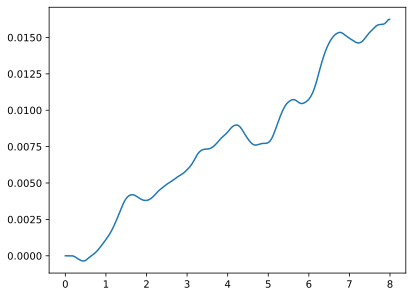

In [3]:
sns.lineplot(x=np.arange(0,8,0.01),y=XSim[0,11,:])

In [26]:
XSim.shape

(35, 20, 800)

In [4]:
from ioc.methods.infer import ApproximateInferenceFactory
from ioc.methods.mle import max_likelihood
from jax import vmap
import jax.numpy as jnp

x0 = dict(
    pos_cost_exp= 5,
    vel_cost_exp=0,
)
res = max_likelihood(CSTProblem, XSim, x0=x0, method="bobyqa")
res

In [18]:
ll = lambda p,v: ApproximateInferenceFactory.create(CSTProblem(
    T=800,
    control_cost_exp=2,
    pos_cost_exp=p,
    vel_cost_exp=v,
)).log_likelihood(XSim[:,11,:][:,None,:])

ll(12,1.5)

Array(195823.54985849, dtype=float64)

In [22]:
inf = ApproximateInferenceFactory.create(problem,soc)
inf.log_likelihood(XSim[:,11,:][:,None,:])

Array(195968.71669449, dtype=float64)

In [27]:
mu, Sigma = inf.conditional_moments(XSim)
mu.shape, Sigma.shape

((799, 20, 70), (799, 20, 70, 70))

In [49]:
from src.ofc_model import get_cst_pos_control, get_cst_vel_control
pos_model = get_cst_pos_control(lam=4)
vel_model = get_cst_vel_control(lam=4)
pos_inf = ApproximateInferenceFactory.create(pos_model)
vel_inf = ApproximateInferenceFactory.create(vel_model)
pos_ll = pos_inf.log_likelihood(XSim[:,11,:][:,None,:])
vel_ll = vel_inf.log_likelihood(XSim[:,11,:][:,None,:])
pos_ll, vel_ll

(Array(195223.9812864, dtype=float64), Array(195990.59960405, dtype=float64))

In [50]:
pos_mu, pos_Sigma = pos_inf.conditional_moments(XSim)
vel_mu, vel_Sigma = vel_inf.conditional_moments(XSim)

In [34]:
pos_mu.shape, vel_mu.shape

((799, 1, 70), (799, 1, 70))

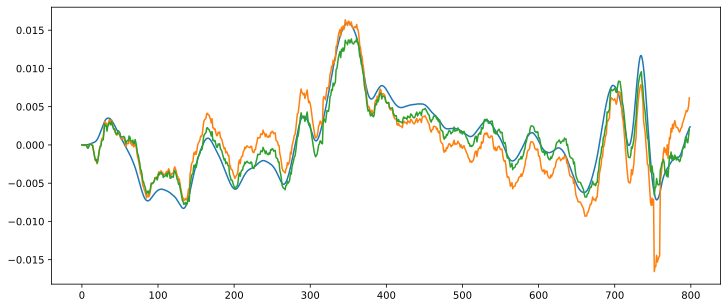

In [52]:
from matplotlib import pyplot as plt
trial = 15
comp = 1
fig,ax = plt.subplots(1,1,figsize=(12,5))
ax.plot(XSim[comp,trial,:], label='sim x')
ax.plot(pos_mu[:,trial,35+comp], label='pos mu x')
ax.plot(vel_mu[:,trial,35+comp], label='vel mu x')

In [62]:
from scipy.io import loadmat
mat_data = loadmat('/Users/raeed/codebase/0-projects/cst-rtt/eLife_code_and_data/data/cst_data.mat')

In [64]:
# Inspect the struct array structure
data_struct = mat_data['data']
print(f"Data struct shape: {data_struct.shape}")
print(f"Data struct dtype: {data_struct.dtype}")
print(f"Field names: {data_struct.dtype.names}")

# Show a sample of the first record to understand field types
if data_struct.size > 0:
    first_record = data_struct[0, 0] if data_struct.ndim > 1 else data_struct[0]
    print("\nFirst record field info:")
    for field_name in data_struct.dtype.names:
        value = first_record[field_name]
        print(f"  {field_name}: {type(value)} shape={getattr(value, 'shape', 'N/A')}")


Data struct shape: (13575, 1)
Data struct dtype: [('subjectID', 'O'), ('trialType', 'O'), ('lambda', 'O'), ('trialNumber', 'O'), ('sessionNumber', 'O'), ('success', 'O'), ('lambdaUpdateMode', 'O'), ('target', 'O'), ('waitTime', 'O'), ('reactionTime', 'O'), ('lambdaWidth', 'O'), ('CIV', 'O'), ('feedback_type', 'O'), ('instruction_type', 'O'), ('t', 'O'), ('x', 'O'), ('u', 'O')]
Field names: ('subjectID', 'trialType', 'lambda', 'trialNumber', 'sessionNumber', 'success', 'lambdaUpdateMode', 'target', 'waitTime', 'reactionTime', 'lambdaWidth', 'CIV', 'feedback_type', 'instruction_type', 't', 'x', 'u')

First record field info:
  subjectID: <class 'scipy.io.matlab._mio5_params.MatlabOpaque'> shape=(1,)
  trialType: <class 'scipy.io.matlab._mio5_params.MatlabOpaque'> shape=(1,)
  lambda: <class 'numpy.ndarray'> shape=(1, 1)
  trialNumber: <class 'numpy.ndarray'> shape=(1, 1)
  sessionNumber: <class 'numpy.ndarray'> shape=(1, 1)
  success: <class 'numpy.ndarray'> shape=(1, 1)
  lambdaUpdateMo

In [70]:
# Convert struct array to DataFrame (preserving MATLAB structure)
# This handles arrays in struct fields by keeping them as-is
import numpy as np


def struct_to_dataframe(mat_struct):
    """Convert a MATLAB struct array to a pandas DataFrame.

    - Flattens the MATLAB struct array to 1D while preserving all rows
    - Keeps array-valued fields as objects so you can unpack later
    """
    data_struct = mat_struct['data'] if isinstance(mat_struct, dict) else mat_struct

    # Ensure we have a 1D view over all records
    data_struct = np.asarray(data_struct).reshape(-1)

    rows = []
    for record in data_struct:
        row = {}
        for field_name in record.dtype.names:
            value = record[field_name]
            row[field_name] = value
        rows.append(row)

    df = pd.DataFrame(rows)
    return df

# Create the basic DataFrame from the struct
df_cst = struct_to_dataframe(mat_data)
print(f"DataFrame shape: {df_cst.shape}")
print(f"Number of rows: {len(df_cst)}")
print(f"DataFrame columns: {df_cst.columns.tolist()}")

# Peek at a couple of rows to verify content (not just a truncated preview)
df_cst.iloc[[0, 1]]


DataFrame shape: (13575, 17)
Number of rows: 13575
DataFrame columns: ['subjectID', 'trialType', 'lambda', 'trialNumber', 'sessionNumber', 'success', 'lambdaUpdateMode', 'target', 'waitTime', 'reactionTime', 'lambdaWidth', 'CIV', 'feedback_type', 'instruction_type', 't', 'x', 'u']


,subjectID,trialType,lambda,trialNumber,sessionNumber,success,lambdaUpdateMode,target,waitTime,reactionTime,lambdaWidth,CIV,feedback_type,instruction_type,t,x,u
0,"[[b'', b'MCOS', b'string', [[3707764736], [2],...","[[b'', b'MCOS', b'string', [[3707764736], [2],...",[[-1]],[[1]],[[0]],[[nan]],"[[b'', b'MCOS', b'string', [[3707764736], [2],...","[[b'', b'MCOS', b'string', [[3707764736], [2],...",[[0.35]],[[0.695000171661377]],[[-1]],[[-1]],[[-1]],[position],"[[0.0], [0.003999948501586914], [0.00699996948...","[[0], [0], [0], [0], [0], [0], [0], [0], [0], ...","[[-1.784637451171875, 1.0144882202148438, -29...."
1,"[[b'', b'MCOS', b'string', [[3707764736], [2],...","[[b'', b'MCOS', b'string', [[3707764736], [2],...",[[-1]],[[2]],[[0]],[[nan]],"[[b'', b'MCOS', b'string', [[3707764736], [2],...","[[b'', b'MCOS', b'string', [[3707764736], [2],...",[[0.35]],[[0.3410000801086426]],[[-1]],[[-1]],[[-1]],[position],"[[0.03500008583068848], [0.03900003433227539],...","[[0], [0], [0], [0], [0], [0], [0], [0], [0], ...","[[68.02618408203125, -1.3444595336914062, -11...."


In [76]:
# Clean MATLAB types: unwrap 1x1 arrays, deeply decode byte strings inside arrays/objects, keep larger arrays
from scipy.io.matlab._mio5_params import MatlabOpaque


_NOISE_STRINGS = {'', 'MCOS', 'string'}


def _first_text(obj):
    """Depth-first search for the first meaningful text element (str/bytes) in a nested container."""
    if isinstance(obj, (bytes, bytearray)):
        try:
            s = obj.decode('utf-8')
        except Exception:
            s = obj
        if isinstance(s, str) and s.strip() not in _NOISE_STRINGS:
            return s.strip()
        else:
            return None
    if isinstance(obj, str):
        if obj.strip() not in _NOISE_STRINGS:
            return obj.strip()
        else:
            return None
    if isinstance(obj, np.ndarray):
        for el in obj.ravel():
            res = _first_text(el)
            if res is not None:
                return res
    if isinstance(obj, (list, tuple)):
        for el in obj:
            res = _first_text(el)
            if res is not None:
                return res
    return None


def _deep_decode(v):
    """Recursively decode MATLAB-loaded bytes/objects to Python types, extracting string content when present."""
    if isinstance(v, (bytes, bytearray)):
        try:
            s = v.decode('utf-8')
        except Exception:
            s = v
        return s
    if isinstance(v, MatlabOpaque):
        return str(v)
    if isinstance(v, np.generic):
        return v.item()
    if isinstance(v, np.ndarray):
        if v.size == 1:
            return _deep_decode(v.item())
        decoded = np.vectorize(_deep_decode, otypes=[object])(v)
        txt = _first_text(decoded)
        if txt is not None:
            return txt
        return np.squeeze(decoded)
    if isinstance(v, (list, tuple)):
        decoded_list = [_deep_decode(x) for x in v]
        txt = _first_text(decoded_list)
        if txt is not None:
            return txt
        return type(v)(decoded_list)
    return v


def clean_struct_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    return df.applymap(_deep_decode)


clean_cst = clean_struct_dataframe(df_cst)
print(clean_cst[['subjectID','trialType']].head())


/var/folders/wf/m89rq9p97kq6fdqj23hkrm_h0000gn/T/ipykernel_97524/947581375.py:67: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return df.applymap(_deep_decode)


                                           subjectID  \
0  [(b'', b'MCOS', b'string', array([[3707764736]...   
1  [(b'', b'MCOS', b'string', array([[3707764736]...   
2  [(b'', b'MCOS', b'string', array([[3707764736]...   
3  [(b'', b'MCOS', b'string', array([[3707764736]...   
4  [(b'', b'MCOS', b'string', array([[3707764736]...   

                                           trialType  
0  [(b'', b'MCOS', b'string', array([[3707764736]...  
1  [(b'', b'MCOS', b'string', array([[3707764736]...  
2  [(b'', b'MCOS', b'string', array([[3707764736]...  
3  [(b'', b'MCOS', b'string', array([[3707764736]...  
4  [(b'', b'MCOS', b'string', array([[3707764736]...  
